In [16]:
from datasets import load_dataset
import tiktoken
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython import display
from pathlib import Path

def ensure_file(file_path):
  base_path = Path(file_path).parent
  Path(base_path).mkdir(parents=True, exist_ok=True)
  return file_path

def get_line_stats(batch, tokenizer):
  tokens_batch = []
  length_batch = []
  for row in batch["text"]:
    tokens = tokenizer.encode(row, allowed_special={"<|endoftext|>"})
    tokens_batch.append(tokens)
    length_batch.append(len(tokens))
  return {"tokens": tokens_batch, "length": length_batch}

def prepare_dataset(name, cache_file, tokenizer, pad_token, target_seq_len):
  # Load the dataset and gather token lengths
  dataset = load_dataset(name, split="train")
  dataset = dataset.map(
    lambda b: get_line_stats(b, tokenizer),
    batched=True,
    remove_columns=["text"]
  )

  # Pad each token sequence into a fixed size
  shape = (len(dataset), max(dataset["length"]) + 1)
  padded = torch.full(shape, pad_token, dtype=torch.int)
  for i, tokens in enumerate(dataset["tokens"]):
    padded[i, :len(tokens)] = torch.tensor(tokens, dtype=torch.int)

  # Split each sequence into chunks and cache them
  num_chunks = padded.shape[1] // target_seq_len
  chunks = torch.chunk(padded, chunks=num_chunks, dim=1)
  torch.save(chunks, cache_file)
  return len(dataset), chunks

In [17]:
def init_weights(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_normal_(module.weight)
    if module.bias is not None:
      nn.init.constant_(module.bias, 0.0)

paramtensor = lambda *args: nn.Parameter(torch.randn(*args))

class Decoder(nn.Module):
  # B x T x E input and output, where B is the batch size, T is the token
  # sequence length and E is the embedding dimension.
  def __init__(self, E, H, D_k, D_f):
    super().__init__()
    self.H, self.D_k = H, D_k
    self.D_k_scale = 1 / torch.sqrt(torch.tensor(self.D_k)).item()

    # Linear projection matrices for the query, key and value
    # B x T x E -> B x H x T x D_k, where H is the number of attention heads and
    # D_k is the query, key and value embedding dimension for each attention head
    self.Q_proj = paramtensor(E, D_k * H)
    self.K_proj = paramtensor(E, D_k * H)
    self.V_proj = paramtensor(E, D_k * H)
    # Output projection for the scaled values of the concatenated attention heads
    self.O_proj = paramtensor(D_k * H, E)

    self.norm1 = nn.LayerNorm(E) # After the multihead self-attention
    self.norm2 = nn.LayerNorm(E) # After the feed forward network

    # Feed forward network: B x T x E -> B x T x D_f -> B x T x E,
    # where D_f is the dimension of the hidden layer
    self.ffn = nn.Sequential(nn.Linear(E, D_f), nn.ReLU(), nn.Linear(D_f, E))

  def forward(self, x, M):
    # Linearly project queries, keys and value for each attention head, perform
    # multi-head masked self-attention on the input, each concatenate each attention
    # head's values and linearly project them back into embedding space.
    B, T = x.shape[0], x.shape[1]
    Q = (x @ self.Q_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    K = (x @ self.K_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    V = (x @ self.V_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)

    # The causal mask ensures that future tokens can't be attended to since e^-inf approaches 0.
    scaled = F.scaled_dot_product_attention(Q, K, V, attn_mask=M)
    # Concatenate each attention head and linearly project the result back into embedding space
    attended = scaled.transpose(1, 2).reshape(B, T, self.H * self.D_k) @ self.O_proj

    # Process the attended values
    x = self.norm1(attended + x)
    ffn_output = self.ffn(x)
    return self.norm2(ffn_output + x)

class Transformer(nn.Module):
  # B x T input and B x T x V output, where B is the batch size, T is the token
  # sequence length. Each token is an index into the vocabulary (V).
  def __init__(self, V, E, T, H, D_k, D_f, L, device):
    super().__init__()
    # Embeddings: B x T -> B x T x E, where E is the embedding dimension
    self.tok_embed = paramtensor(V, E)
    self.pos_embed = paramtensor(T, E)
    self.E_scale = torch.sqrt(torch.tensor(E)).item()

    # Share the same causal mask for all decoders to save memory
    temp = torch.full((T, T), float("-inf"), device=device)
    self.causal_mask = torch.triu(temp, diagonal=1).to(device)

    # Transformer decoder layers are referred to as decoders because of their
    # auto-regressive masked self-attention, not because of their structure.
    self.layers = nn.ModuleList([Decoder(E, H, D_k, D_f) for _ in range(L)])

  def forward(self, x):
    # Each token selects a row from the learned token embedding matrix.
    embeddings = self.tok_embed[x] * self.E_scale + self.pos_embed
    for layer in self.layers:
      embeddings = layer(embeddings, self.causal_mask)

    # Convert embeddings back into tokens by creating a B x T x V logit matrix. During
    # training, the difference between the actual next token and the most probable next
    # token will be minimized. During inference, the next most probable token will be selected.
    return embeddings @ self.tok_embed.T

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset_name = "BabyLM-community/BabyLM-2026-Strict-Small"
data_cache_file = ensure_file(".cache/prepared-dataset.pth")
model_cache_file = ensure_file(".cache/model-weights.pth")
experiment_name = "Overfit test"

tokenizer = tiktoken.encoding_for_model("gpt2")
# EOS token = Pad token to minimize the vocab size
eos_token = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
target_seq_len, batch_size, num_steps = 512, 16, 10000

try:
  chunks = torch.load(data_cache_file)
  total_rows = chunks[0].shape[0]
except:
  total_rows, chunks = prepare_dataset(dataset_name, data_cache_file,
                           tokenizer, eos_token, target_seq_len)

seq_len = chunks[0].shape[1]
num_train_rows = total_rows // 2
shuffled = torch.randperm(num_train_rows)
iter_steps = len(chunks) * num_train_rows // batch_size
num_iters = num_steps // iter_steps

model = Transformer(tokenizer.n_vocab, 512, seq_len,
                    12, 8, 2048, 12, device).to(device)
model.apply(init_weights)

num_parmas = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Using {device} to run a {num_parmas} parameter model")

Using cuda to run a 53623808 parameter model


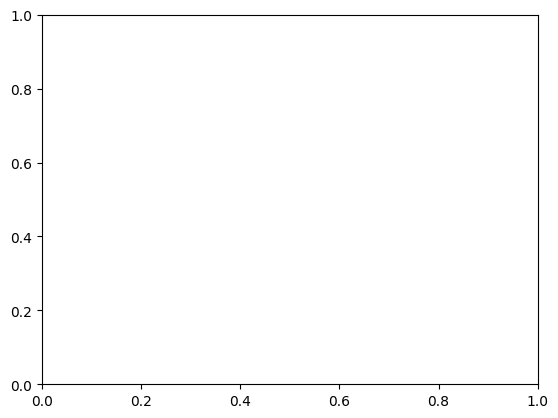

In [19]:
# Train the model
model.train()
torch.enable_grad()

optimizer = Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss()
fig, ax = plt.subplots()
train_losses = []

for _ in range(num_iters):
  for i in range(0, num_train_rows, batch_size):
    indices = shuffled[i: i + batch_size]
    batch_losses = []

    # TODO: do this in parallel
    for j in range(len(chunks)):
      optimizer.zero_grad(set_to_none=False)

      # The correct next token is the sequence shifted to the left
      rows = chunks[j][indices].to(device)
      print(rows.shape[1], seq_len)
      if rows.shape[1] < seq_len:
        break # TODO: find the actual cause for this

      target = torch.full(rows.shape, eos_token, dtype=torch.long, device=device)
      target[:, :-1] = rows[:, 1:]

      prediction = model(rows)
      # B x T x V -> B x V x T as pytorch expects
      loss = criterion(prediction.permute(0, 2, 1), target)
      batch_losses.append(loss.item())
      loss.backward()
      optimizer.step()

    # Plot a loss curve in real time
    mean_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(mean_loss)
    #clear_output(wait=True)
    #ax.clear()

    #ax.plot(train_losses, "r-")
    #ax.autoscale_view(scalex=True, scaley=True)
    #fig.suptitle(experiment_name, fontsize=14, fontweight="bold")
    #ax.set_title(f"Batch loss: {mean_loss:.2f}")
    #ax.set_xlabel("Batch")
    #ax.set_ylabel("Loss")

    #fig.tight_layout() # Prevents overlapping labels
    #display.display(fig)

fig.savefig(f"{experiment_name}.png", dpi=300, bbox_inches="tight")
torch.save(model.state_dict(), model_cache_file)

In [20]:
"""
TODO:
- What is the test loss?
- Ensure that we can overfit a tiny dataset
- How does test loss improve as the model capacity grows (can we recreate the scaling laws)?
- Compare performance with and without adding dropout to the embedding weights
- Compare performance with and without scaling the embeddings. Does it make any noticale difference?
- Compare model performance using the original transformer, GPT-1, GPT-2, GPT-3 architectures
- Compare performance using learned positional embeddings and rotary positional embeddings: https://arxiv.org/pdf/2104.09864
- Compare training and inference speeds with and without a KV cache
- Visualize the attention heads throughout training
- Add model quantization to reduce memory requirements: https://wandb.ai/byyoung3/Generative-AI/reports/Quantization-Aware-Training-QAT-A-step-by-step-guide-with-PyTorch--VmlldzoxMTk2NTY2Mw
- Read distillation paper and attempt to distill to a much smaller model
"""

model.eval()
torch.no_grad()

#weights = torch.load(model_cache_file, weights_only=True)
#model.load_state_dict(weights)

row = torch.randint(low=num_train_rows, high=total_rows, size=(1,))
sequence = chunks[0][row]
prediction = model(sequence.to(device))
next_tokens = torch.argmax(prediction, dim=-1)

# Ok, we've either completely fucked up somewhere, or the model/dataset is just too small???
# Maybe we should ignoring the <|endoftext|> when visualizing the output text

print("Input sequence:", tokenizer.decode(sequence.tolist()[0]))
print("Predicted sequence:", tokenizer.decode(next_tokens.tolist()[0]))

Input sequence: *MOT:	oh they're so cute.<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftex